# Premier League Match Predictor Projcect

The English Premier League is a football league consisting of 20 teams that runs between August and May every year. Each game produces results from scoreless draws, to crazy blow-outs, and dramatic upsets. In this project, I develop two machine learning models based on Random Forests to predict match outcomes in the Premier League. The first model is a Random Forest Classifier, which predicts the categorical result of a match (Home win, Draw, or Away win). The second model is a Random Forest Regressor, which predicts the final score by estimating the number of goals scored by each team. 

Both models are trained on historical match data and only rely on pre-match data to determine results.

## 1. Import Libraries
Import all necessary libraries for data manipulation, visualization, and modeling.

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    classification_report,
    r2_score
)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit


import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load and Preview Data
Load the dataset and display the first few rows to understand its structure.

In [2]:
data = pd.read_csv("epl_final.csv")
print(data.shape)
data.head()


(9380, 22)


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0


## 3. Preprocess Data
Drop unnecessary columns and prepare the data for modeling.

In [3]:
data = data.drop(columns=[
    'HalfTimeHomeGoals', 'HalfTimeAwayGoals', 'HalfTimeResult',
    'HomeFouls', 'AwayFouls',
    'HomeRedCards', 'AwayRedCards'
])


In [4]:
data.dropna(inplace=True)

data.shape

(9380, 15)

Theres no change to the amount of rows, so there was no null values.

In [5]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeYellowCards,AwayYellowCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,17,8,14,4,6,6,1,2
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,17,12,10,5,7,7,1,2
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,6,16,3,9,8,4,5,3
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,6,13,4,6,5,8,1,1
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,17,12,8,6,6,4,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,12,14,6,5,7,4,0,2
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,5,13,2,5,1,4,2,1
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,11,7,2,2,1,3,2,2
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,17,11,7,2,3,6,2,2


## 4. Train/Test Split
Split the data into training and testing sets based on season. Seasons between 2019-20 and 2023-24 will be used for training, and 2024-25 will be used to test

In [6]:
train_data = data[data['Season'].between('2019/20', '2023/24')]
test_data  = data[data['Season'] == '2024/25']


## 5. Feature Engineering

I create rolling average features to represent recent team form, which are then used as inputs to the models. Reasons I used the features I did was based on my intuition. Offensive and defensive strength are represented through these features, such as average goals scored/conceded in past 5 matches, and average yellow cards. 



In [7]:
def add_form_features(df, window=5):
    df = df.sort_values('MatchDate')

    df['HomeAvgGF_5'] = (
        df.groupby('HomeTeam')['FullTimeHomeGoals']
          .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )

    df['HomeAvgGA_5'] = (
        df.groupby('HomeTeam')['FullTimeAwayGoals']
          .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )

    df['AwayAvgGF_5'] = (
        df.groupby('AwayTeam')['FullTimeAwayGoals']
          .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )

    df['AwayAvgGA_5'] = (
        df.groupby('AwayTeam')['FullTimeHomeGoals']
          .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )
    df['HomeAvgShotsOnTarget_5'] = (
        df.groupby('HomeTeam')['HomeShotsOnTarget']
          .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )
    df['AwayAvgShotsOnTarget_5'] = (
        df.groupby('AwayTeam')['AwayShotsOnTarget']
          .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )
    df['HomeAvgCorners_5'] = (
        df.groupby('HomeTeam')['HomeCorners']
          .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )
    df['AwayAvgCorners_5'] = (
        df.groupby('AwayTeam')['AwayCorners']
          .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )
      # Create a binary column: 1 if home win, 0 otherwise
    df['HomeWin'] = (df['FullTimeResult'] == 'H').astype(int)

    # Compute rolling win rate for each home team (only for home games)
    df['HomeTeamHomeWinRate_5'] = (
        df.sort_values('MatchDate')
          .groupby('HomeTeam')['HomeWin']
          .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )
    df['HomeTeamHomeWinRate_5'].fillna(0.5, inplace=True)

    # Create a binary column: 1 if Away win, 0 otherwise
    df['AwayWin'] = (df['FullTimeResult'] == 'A').astype(int)

    df['AwayTeamAwayWinRate_5'] = (
        df.sort_values('MatchDate')
          .groupby('AwayTeam')['AwayWin']
          .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )
    df['AwayTeamAwayWinRate_5'].fillna(0.5, inplace=True)

    df['HomeAvgYC_5'] = (
      df.groupby('HomeTeam')['HomeYellowCards']
        .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )

    df['AwayAvgYC_5'] = (
      df.groupby('AwayTeam')['AwayYellowCards']
        .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )
    
    df['MatchDate'] = pd.to_datetime(df['MatchDate'])
    df['HomeDaysRest'] = (
        df.groupby('HomeTeam')['MatchDate']
          .diff().dt.days.fillna(7)
    )
    df['AwayDaysRest'] = (
      df.groupby('AwayTeam')['MatchDate']
        .diff().dt.days.fillna(7)
    )

    return df


Adding rolling averages helps to see a teams recent performance, because that would matter more compared to games played years ago.

In [8]:
train_data = add_form_features(train_data)
test_data  = add_form_features(test_data)

train_data.head()

C:\Users\nadim\AppData\Local\Temp\ipykernel_9116\2919474000.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['HomeTeamHomeWinRate_5'].fillna(0.5, inplace=True)
C:\Users\nadim\AppData\Local\Temp\ipykernel_9116\2919474000.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,...,HomeAvgCorners_5,AwayAvgCorners_5,HomeWin,HomeTeamHomeWinRate_5,AwayWin,AwayTeamAwayWinRate_5,HomeAvgYC_5,AwayAvgYC_5,HomeDaysRest,AwayDaysRest
7130,2019/20,2019-08-09,Liverpool,Norwich,4,1,H,15,12,7,...,11.0,2.0,1,0.5,0,0.5,0.0,2.0,7.0,7.0
7131,2019/20,2019-08-10,West Ham,Man City,0,5,A,5,14,3,...,1.0,1.0,0,0.5,1,0.5,2.0,2.0,7.0,7.0
7132,2019/20,2019-08-10,Bournemouth,Sheffield United,1,1,D,13,8,3,...,3.0,4.0,0,0.5,0,0.5,2.0,1.0,7.0,7.0
7133,2019/20,2019-08-10,Burnley,Southampton,3,0,H,10,11,4,...,2.0,7.0,1,0.5,0,0.5,0.0,0.0,7.0,7.0
7134,2019/20,2019-08-10,Crystal Palace,Everton,0,0,D,6,10,2,...,6.0,2.0,0,0.5,0,0.5,2.0,1.0,7.0,7.0


Here, feature engineering is applied to the dataset, and you can see how the first 5 rows look.

## 6. Model Training
Train Random Forest models to predict match goals and results. We make the training and testing sets for each model, and select relevant columns.

In [9]:
features = [
    'HomeAvgGF_5', 'HomeAvgGA_5',
    'AwayAvgGF_5', 'AwayAvgGA_5',
    'HomeTeamHomeWinRate_5', 'AwayTeamAwayWinRate_5',
    'HomeAvgYC_5', 'AwayAvgYC_5',
    'HomeDaysRest', 'AwayDaysRest', 
    'HomeAvgShotsOnTarget_5', 'AwayAvgShotsOnTarget_5',
    'HomeAvgCorners_5', 'AwayAvgCorners_5'
]

X_train = train_data[features]
X_test  = test_data[features]

# Regression targets
y_train_goals = train_data[['FullTimeHomeGoals', 'FullTimeAwayGoals']]
y_test_goals  = test_data[['FullTimeHomeGoals', 'FullTimeAwayGoals']]

# Classification targets
y_train_result = train_data['FullTimeResult']
y_test_result  = test_data['FullTimeResult']


 ### Hyperparameter Tuning

To help improve the model, hyperparameters for both the classifier and regressor are tuned using GridSearchCV. TimeSeriesSplit cross-validation strategy is used to ensure that training data always comes before validation data chronologically, whoch prevents future information from leaking into the training process.
**Tuned hyperparameters include:**
- `n_estimators`: number of trees in the forest
- `max_depth`: maximum depth of each decision tree
- `min_samples_split` and `min_samples_leaf`: control overfitting by enforcing minimum data requirements
- `max_features` (regression): number of features considered when splitting


In [10]:

tscv = TimeSeriesSplit(n_splits=5)

param_grid_clf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

param_grid_reg = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}


### Classification

For this model, we would like to see just the match's outcome. Random Forest Classifier model will be used, below are the potential outcomes: 

- `H`: Home Win
- `D`: Draw
- `A`: Away Win

In [11]:
# For classification

clf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_clf,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
)

clf_grid.fit(X_train, y_train_result)

print("Best classification params:", clf_grid.best_params_)
print("Best CV accuracy:", clf_grid.best_score_)



Best classification params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best CV accuracy: 0.6240506329113924


A best cross validation accuracy of 62.4%. Not bad. Lets train the final dataset with the best parameters.

In [12]:
# Train final classification model
final_clf = RandomForestClassifier(**clf_grid.best_params_, random_state=42, n_jobs=-1,class_weight = {
    'A': 1,
    'D': 2.5,
    'H': 1
})
final_clf.fit(X_train, y_train_result)

# Test set evaluation
result_preds = final_clf.predict(X_test)
result_accuracy = accuracy_score(y_test_result, result_preds)
print(f"Test accuracy (H/D/A): {result_accuracy}")

Test accuracy (H/D/A): 0.6257142857142857


A test accuracy of 62.57%. Essentially the same as the best cross-validation accuracy. Meaning the model correctly guesses a match's outcome 62.57% of the time.

Lets see how the model performs using a confusion matrix.

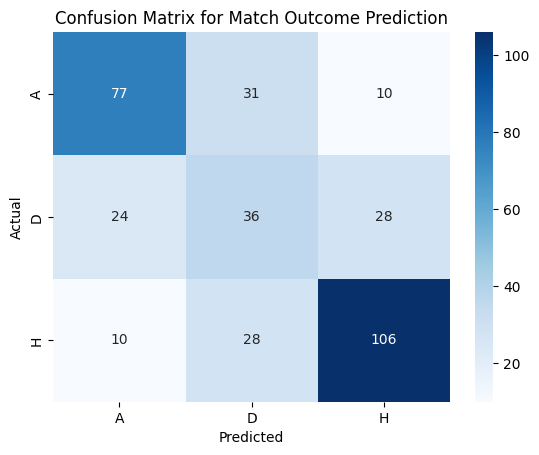


Classification Report:
               precision    recall  f1-score   support

           A       0.69      0.65      0.67       118
           D       0.38      0.41      0.39        88
           H       0.74      0.74      0.74       144

    accuracy                           0.63       350
   macro avg       0.60      0.60      0.60       350
weighted avg       0.63      0.63      0.63       350



In [13]:
cm = confusion_matrix(y_test_result, result_preds)


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['A','D','H'], yticklabels=['A','D','H'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Match Outcome Prediction")
plt.show()
print("\nClassification Report:\n",
      classification_report(y_test_result, result_preds))

We can see the model struggles with predicting draws, but does fairly well when predicting home or away wins. The f1-score backs this, performing best on Home wins (~0.74), fairly well on Away wins (~0.67), but subpar on Draws (~0.39).

In [14]:
# Feature importance
clf_features = pd.DataFrame(
    final_clf.feature_importances_,
    index=X_train.columns,
    columns=['Importance']
).sort_values(by='Importance', ascending=False)
print(clf_features)

                        Importance
HomeAvgGF_5               0.130755
AwayAvgGA_5               0.114145
AwayAvgGF_5               0.106611
HomeAvgGA_5               0.100867
HomeAvgShotsOnTarget_5    0.080724
AwayAvgShotsOnTarget_5    0.073821
HomeAvgCorners_5          0.060333
AwayAvgCorners_5          0.056900
HomeDaysRest              0.056225
AwayDaysRest              0.052690
AwayAvgYC_5               0.048829
HomeAvgYC_5               0.047756
HomeTeamHomeWinRate_5     0.038671
AwayTeamAwayWinRate_5     0.031672


We can see goals play a big part in the model for determining a match's outcome, whether its goals for, or goals against Home/Away. Surprisingly, a teams win rate at home/on the road doesn't play a huge part in the models prediction.

### Regression

For this model, we would like to see the final score of a match. We will predict each teams final goal count using RandomForestRegressor. Also, we'll derive who wins from the score and compare it to the Classification method to see which performs better.

In [15]:
# For regression
reg_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_reg,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

reg_grid.fit(X_train, y_train_goals)

print("Best regression params:", reg_grid.best_params_)
print("Best CV MAE:", -reg_grid.best_score_)

Best regression params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MAE: 0.8017822279820912


A mean absolute error of 0.8017. It means were off by that many goals on average per team, per match.

In [16]:
final_reg = RandomForestRegressor(**reg_grid.best_params_, random_state=42, n_jobs=-1, criterion='absolute_error')
final_reg.fit(X_train, y_train_goals)

# Test set predictions
goal_preds = final_reg.predict(X_test)

mae_home = mean_absolute_error(y_test_goals['FullTimeHomeGoals'], goal_preds[:,0])
mae_away = mean_absolute_error(y_test_goals['FullTimeAwayGoals'], goal_preds[:,1])
print(f"MAE Home Goals: {mae_home:.3f}, Away Goals: {mae_away:.3f}")

print(f'MSE home goals: {mean_squared_error(y_test_goals['FullTimeHomeGoals'], goal_preds[:,0])}')
print(f'MSE away goals: {mean_squared_error(y_test_goals['FullTimeAwayGoals'], goal_preds[:,1])}')
home_baseline_mse = np.mean((y_test_goals['FullTimeHomeGoals'] - np.mean(y_test_goals['FullTimeHomeGoals']))**2)
away_baseline_mse = np.mean((y_test_goals['FullTimeAwayGoals'] - np.mean(y_test_goals['FullTimeAwayGoals']))**2)

print(f'Home baseline MSE: {home_baseline_mse:.3f}')
print(f'Away baseline MSE: {away_baseline_mse:.3f}')

print(f'R Squared Home Goals: {r2_score(y_test_goals["FullTimeHomeGoals"], goal_preds[:,0]):.3f}')
print(f'R Squared Away Goals: {r2_score(y_test_goals["FullTimeAwayGoals"], goal_preds[:,1]):.3f}')
print(f'R Squared Total Goals: {r2_score(y_test_goals, goal_preds):.3f}')



MAE Home Goals: 0.741, Away Goals: 0.674
MSE home goals: 0.9306987857142857
MSE away goals: 0.7746517857142857
Home baseline MSE: 1.666
Away baseline MSE: 1.428
R Squared Home Goals: 0.441
R Squared Away Goals: 0.457
R Squared Total Goals: 0.449


On average the MAE is off by less than one goal per team, per match. The MSE is substancially lower than the baseline MSE on predicting historical mean, indicating the models btter than a average-based prediction. The R^2 values show that roughly 45% of all variation of goals explained by the models features.

In [17]:
exact_score_accuracy = np.mean(
    (goal_preds[:, 0].round() == y_test_goals['FullTimeHomeGoals'].values) &
    (goal_preds[:, 1].round() == y_test_goals['FullTimeAwayGoals'].values)
)
print(f"\nExact score accuracy: {exact_score_accuracy:.3f}")


Exact score accuracy: 0.214


The model correctly predicts the score 21.4% of the time during the 2024/25 season. This might seem low, but correct score prediction in soccer is an extremely difficult task due to its high randomness (injuries, upsets, red cards etc.). It seems the models capturing meaningful patterns in the data.

In [18]:
reg_features = pd.DataFrame(
    final_reg.feature_importances_,
    index=X_train.columns,
    columns=['Importance']
).sort_values(by='Importance', ascending=False)
print(reg_features)

                        Importance
HomeAvgGF_5               0.151547
AwayAvgGA_5               0.125499
HomeAvgGA_5               0.120291
AwayAvgGF_5               0.113341
HomeAvgShotsOnTarget_5    0.084848
AwayAvgShotsOnTarget_5    0.068546
AwayAvgCorners_5          0.049754
HomeAvgCorners_5          0.048616
HomeAvgYC_5               0.044832
HomeDaysRest              0.044530
AwayDaysRest              0.043276
AwayAvgYC_5               0.042771
HomeTeamHomeWinRate_5     0.031702
AwayTeamAwayWinRate_5     0.030447


Models predictions were dominated by goals/shots by either team, similar to the classification method. Compared to the classification model, more features receive a low importance (below 5%), indicating that predicting exact scores depends more on a limited set of highly influential predictors.

# 11. Results and Interpretation
Display predictions and summarize the model's performance on test data.

The model has some good numbers! Now, lets see how it is on individual performances. 

Below, minor cleaning and additional attributes are being added.

In [66]:
results_df = test_data.copy()

results_df['Pred_HomeGoals'] = goal_preds[:, 0].round()
results_df['Pred_AwayGoals'] = goal_preds[:, 1].round()
results_df['Pred_Result_Classifier'] = result_preds
results_df['Pred_Result_From_Predicted_Goals'] = np.where(
    results_df['Pred_HomeGoals'] > results_df['Pred_AwayGoals'], 'H',
    np.where(results_df['Pred_HomeGoals'] < results_df['Pred_AwayGoals'], 'A', 'D')
    )

results_df[[
    'MatchDate',
    'HomeTeam', 'AwayTeam',
    'FullTimeHomeGoals', 'FullTimeAwayGoals', 'FullTimeResult',
    'Pred_HomeGoals', 'Pred_AwayGoals', 'Pred_Result_From_Predicted_Goals', 'Pred_Result_Classifier'
]].tail()


,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,Pred_HomeGoals,Pred_AwayGoals,Pred_Result_From_Predicted_Goals,Pred_Result_Classifier
9377,2025-05-04,West Ham,Tottenham,1,1,D,1.0,1.0,D,H
9378,2025-05-04,Chelsea,Liverpool,3,1,H,2.0,1.0,H,H
9375,2025-05-04,Brentford,Man United,4,3,H,2.0,1.0,H,H
9376,2025-05-04,Brighton,Newcastle,1,1,D,2.0,1.0,H,D
9379,2025-05-05,Crystal Palace,Nott'm Forest,1,1,D,2.0,1.0,H,H


Now that we got all our information, lets style the table and display the last 20 games of the season. It will be colour coded, where:
- `Red`: Correct prediction
- `Yellow`: One goal off
- `Green`: Incorrect prediction

Red and Green will be visible for result and goal predictions, and yellow will only be present for goal predicitons.

In [59]:
def highlight_goals_and_result(row):
    styles = [''] * len(row)
    # --- Home Goals ---
    diff_home = abs(row['Pred_HomeGoals'] - row['FullTimeHomeGoals'])
    if diff_home == 0:
        styles[row.index.get_loc('Pred_HomeGoals')] = "background-color: #c6efce; color: #222"
    elif diff_home == 1:
        styles[row.index.get_loc('Pred_HomeGoals')] = "background-color: #fff2cc; color: #222"
    else:
        styles[row.index.get_loc('Pred_HomeGoals')] = "background-color: #ffc7ce; color: #222"
    # --- Away Goals ---
    diff_away = abs(row['Pred_AwayGoals'] - row['FullTimeAwayGoals'])
    if diff_away == 0:
        styles[row.index.get_loc('Pred_AwayGoals')] = "background-color: #c6efce; color: #222"
    elif diff_away == 1:
        styles[row.index.get_loc('Pred_AwayGoals')] = "background-color: #fff2cc; color: #222"
    else:
        styles[row.index.get_loc('Pred_AwayGoals')] = "background-color: #ffc7ce; color: #222"
    # --- Predicted Result from Goals ---
    if row['Pred_Result_From_Predicted_Goals'] == row['FullTimeResult']:
        styles[row.index.get_loc('Pred_Result_From_Predicted_Goals')] = "background-color: #c6efce; color: #222"
    else:
        styles[row.index.get_loc('Pred_Result_From_Predicted_Goals')] = "background-color: #ffc7ce; color: #222"
    # --- Predicted Result from Classifier ---
    if row['Pred_Result_Classifier'] == row['FullTimeResult']:
        styles[row.index.get_loc('Pred_Result_Classifier')] = "background-color: #c6efce; color: #222"
    else:
        styles[row.index.get_loc('Pred_Result_Classifier')] = "background-color: #ffc7ce; color: #222"

    return styles



In [61]:
display(
    results_df.tail(30)[[
        'Pred_HomeGoals', 'Pred_AwayGoals',
        'Pred_Result_From_Predicted_Goals', 'Pred_Result_Classifier',
        'FullTimeHomeGoals', 'FullTimeAwayGoals', 'FullTimeResult'
    ]].style.apply(highlight_goals_and_result, axis=1)
)

,Pred_HomeGoals,Pred_AwayGoals,Pred_Result_From_Predicted_Goals,Pred_Result_Classifier,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult
9350,2.000000,2.000000,D,A,4,2,H
9351,1.000000,1.000000,D,D,0,0,D
9352,1.000000,1.000000,D,D,0,2,A
9353,1.000000,1.000000,D,H,1,1,D
9354,3.000000,1.000000,H,H,4,1,H
9357,1.000000,1.000000,D,A,0,1,A
9358,0.000000,3.000000,A,A,0,1,A
9356,1.000000,3.000000,A,A,0,4,A
9355,1.000000,1.000000,D,D,1,2,A
9359,2.000000,2.000000,D,H,1,2,A


From this small sample size, you can see that the model rarely is off by more than one goal. Out of 60 individual team goal predictions:
- Only 5 (~8%) were more than one goal off. 
- 31 predictions(~52%) performances were off by one goal.
- 24 predictions (40%)performances were spot on.

Results from the classifier and regressor seem to perform similarily, having the same amount of incorrect predictions. We will explore this further below with bar graphs to better visualize the differences.

This visual helps the understanding of the models performance at a glance, and helps us grasp its overall performance.

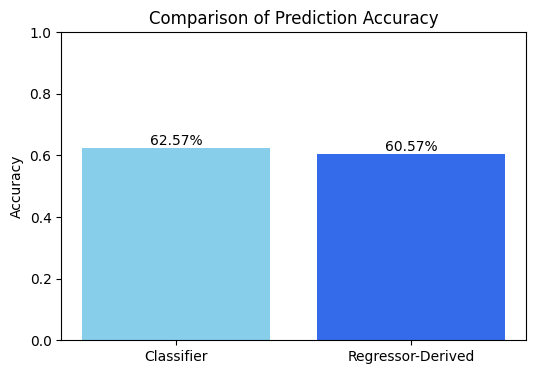

In [67]:
# True if prediction matches the actual result
results_df['Classifier_Correct'] = (
    results_df['Pred_Result_Classifier'] == results_df['FullTimeResult']
)

results_df['Regressor_Derived_Correct'] = (
    results_df['Pred_Result_From_Predicted_Goals'] == results_df['FullTimeResult']
)

classifier_accuracy = results_df['Classifier_Correct'].mean()
regressor_accuracy = results_df['Regressor_Derived_Correct'].mean()


# Put the accuracies into a Series for easy plotting
accuracies = pd.Series(
    [classifier_accuracy, regressor_accuracy],
    index=['Classifier', 'Regressor-Derived']
)

plt.figure(figsize=(6,4))
bars = plt.bar(accuracies.index, accuracies.values, color=['skyblue', '#346beb'])

# Add text labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.2%}', ha='center')

plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Comparison of Prediction Accuracy')
plt.show()



The classifier slightly out-performs the regressor derived predictor. Both models show similar patterns in prediction, and this small difference is not enough to say classifier is outright better

In [69]:
df_plot = pd.DataFrame({
    'Actual': y_test_goals.values.flatten(),   # convert to NumPy 1D
    'Predicted': goal_preds.flatten()
})


C:\Users\nadim\AppData\Local\Temp\ipykernel_9116\1307502241.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Actual', y='Predicted', data=df_plot, palette='Blues')


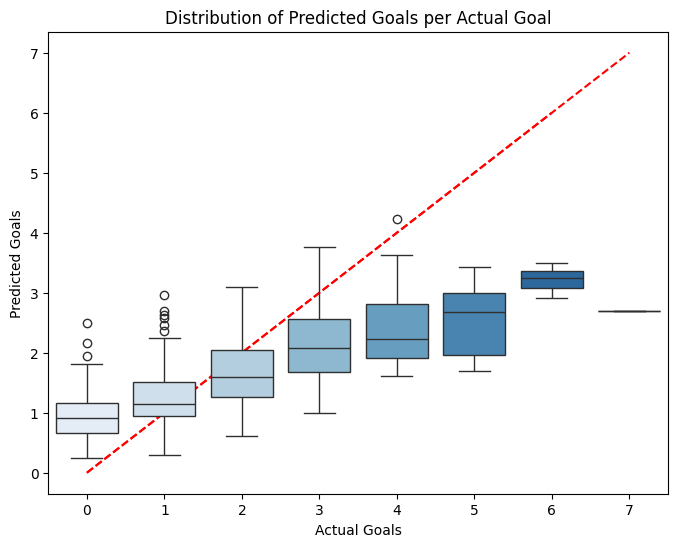

: 

In [ ]:

# Make a DataFrame for convenience



plt.figure(figsize=(8,6))
plt.plot([y_test_goals.min(), y_test_goals.max()],
         [y_test_goals.min(), y_test_goals.max()], 'r--')  # ideal 45-degree line
sns.boxplot(x='Actual', y='Predicted', data=df_plot, palette='Blues')
plt.xlabel("Actual Goals")
plt.ylabel("Predicted Goals")
plt.title("Distribution of Predicted Goals per Actual Goal")
plt.show()



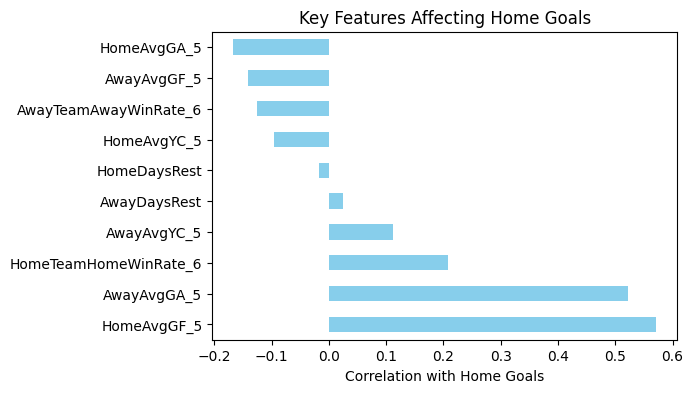

In [ ]:

# Make a copy of your features
corr_matrix = X_train.copy()

# Add the target column
corr_matrix['HomeGoals'] = train_data['FullTimeHomeGoals']
home_corr = corr_matrix.corr()['HomeGoals'].sort_values(ascending=False)

home_corr_filtered = home_corr[home_corr.index != 'HomeGoals']

home_corr_filtered.plot(kind='barh', figsize=(6,4), color='skyblue')
plt.xlabel("Correlation with Home Goals")
plt.title("Key Features Affecting Home Goals")
plt.show()
